#### A) Conjugate Linear Regression (posterior, predictive, evidence)

You observe
$$
X = \begin{bmatrix}
1 & 0 \\
1 & 1 \\
1 & 2
\end{bmatrix}, \quad
y = \begin{bmatrix}
0.2 \\
1.1 \\
1.9
\end{bmatrix}.
$$

Model:
$$
y \mid w \sim \mathcal{N}(Xw, \sigma^2 I), \quad \text{prior } w \sim \mathcal{N}(0, \alpha^{-1} I_2).
$$
Use: $\sigma^2 = 0.10$, $\alpha = 4$.

1) Derive $p(w \mid y, X)$ and compute its mean and covariance.

2) Compute $p(y^* \mid x^*, y, X)$ at $x^* = \begin{bmatrix}1 \\ 1\end{bmatrix}$.

3) Compute $\log p(y \mid X, \sigma^2, \alpha)$ (the evidence).

4) Compute $w_{\text{ML}}$ and $w_{\text{MAP}}$; interpret the shrinkage.
5) Determine the analytical distribution $p(y| w, X, \sigma^2)$

_______________________________

#### B) GP regression (kernel effects, predictive, evidence)}

Inputs: 
$$
x = [0,\ 0.5,\ 1.0,\ 1.5]^T,\quad y = [0.1,\ 0.7,\ 0.9,\ 0.2]^T
$$

Kernel:
$$
k(x, x') = \sigma_f^2 \exp\left( -\frac{(x - x')^2}{2\ell^2} \right), \quad \text{Use } \sigma_f^2 = 1.0,\ \ell = 0.6,\ \sigma_n^2 = 0.05
$$

1. Form $K$ and $K_y = K + \sigma_n^2 I$

2. Compute posterior mean/variance at $ x_* = \{0.25,\ 0.75,\ 1.25\} $

3. Compute $ \log p(y \mid X, \boldsymbol{\theta})$

4. Halve the kernel scale: use $0.5\,\ell$. Predict again at $ x_* $ and explain the change in mean/variance

5. Is this kernel stationary? Isotropic? Justify.


#### C) GP classification (Laplace + probit predictive)}

Binary labels $t \in \{0,1\}$ at
$\mathbf{x} = [-1,\,0,\,1]^{\top}$,
$\mathbf{t} = [0,\,1,\,1]^{\top}$.
Same RBF kernel as above with $\sigma_f^2 = 1$, $\ell = 1$.
Likelihood (probit): $p(t_i=1 \mid f_i)=\Phi(f_i)$.


-  Write the log-posterior
$$
\log p(\mathbf{f}\mid \mathbf{t})
= \log p(\mathbf{t}\mid \mathbf{f})
-\tfrac{1}{2}\mathbf{f}^{\top}K^{-1}\mathbf{f}
-\tfrac{1}{2}\log|K| + c .
$$


- Give the Newton step to locate $\hat{\mathbf{f}}$
(define $W$ and the system solved each iteration).

- Write the Laplace covariance
$$S = \bigl(K^{-1}+W\bigr)^{-1}.$$

- For $x_* = 0.5$, write the probit predictive approximation
$$
p(t_*=1 \mid \mathbf{t})
\quad\text{using}\quad
\mathbb{E}_{f_*}\!\left[\Phi(f_*)\right]
\ \text{under the Laplace Gaussian; evaluate numerically.}
$$


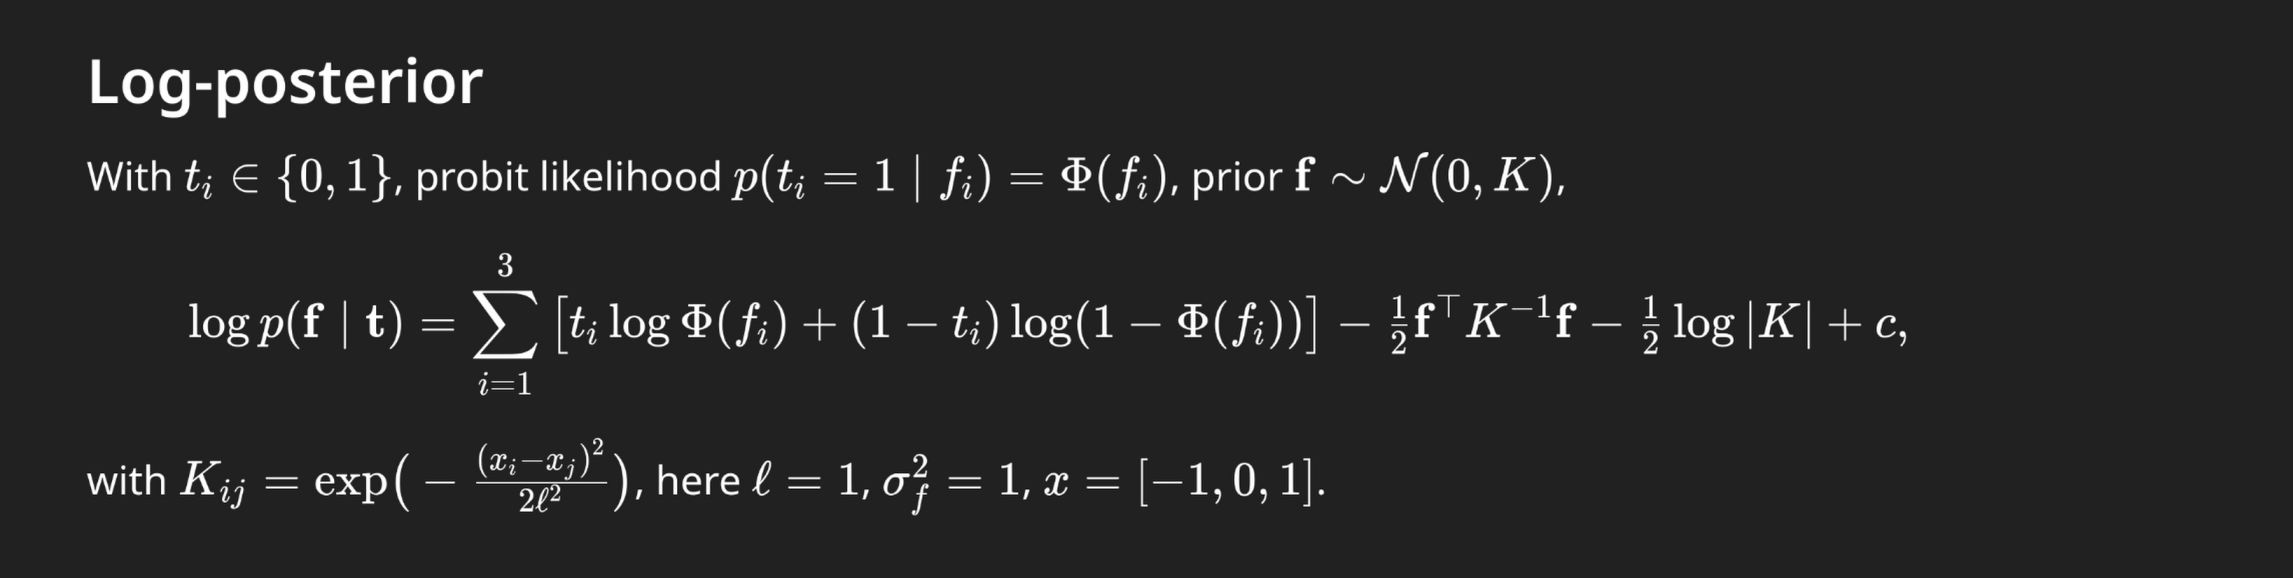
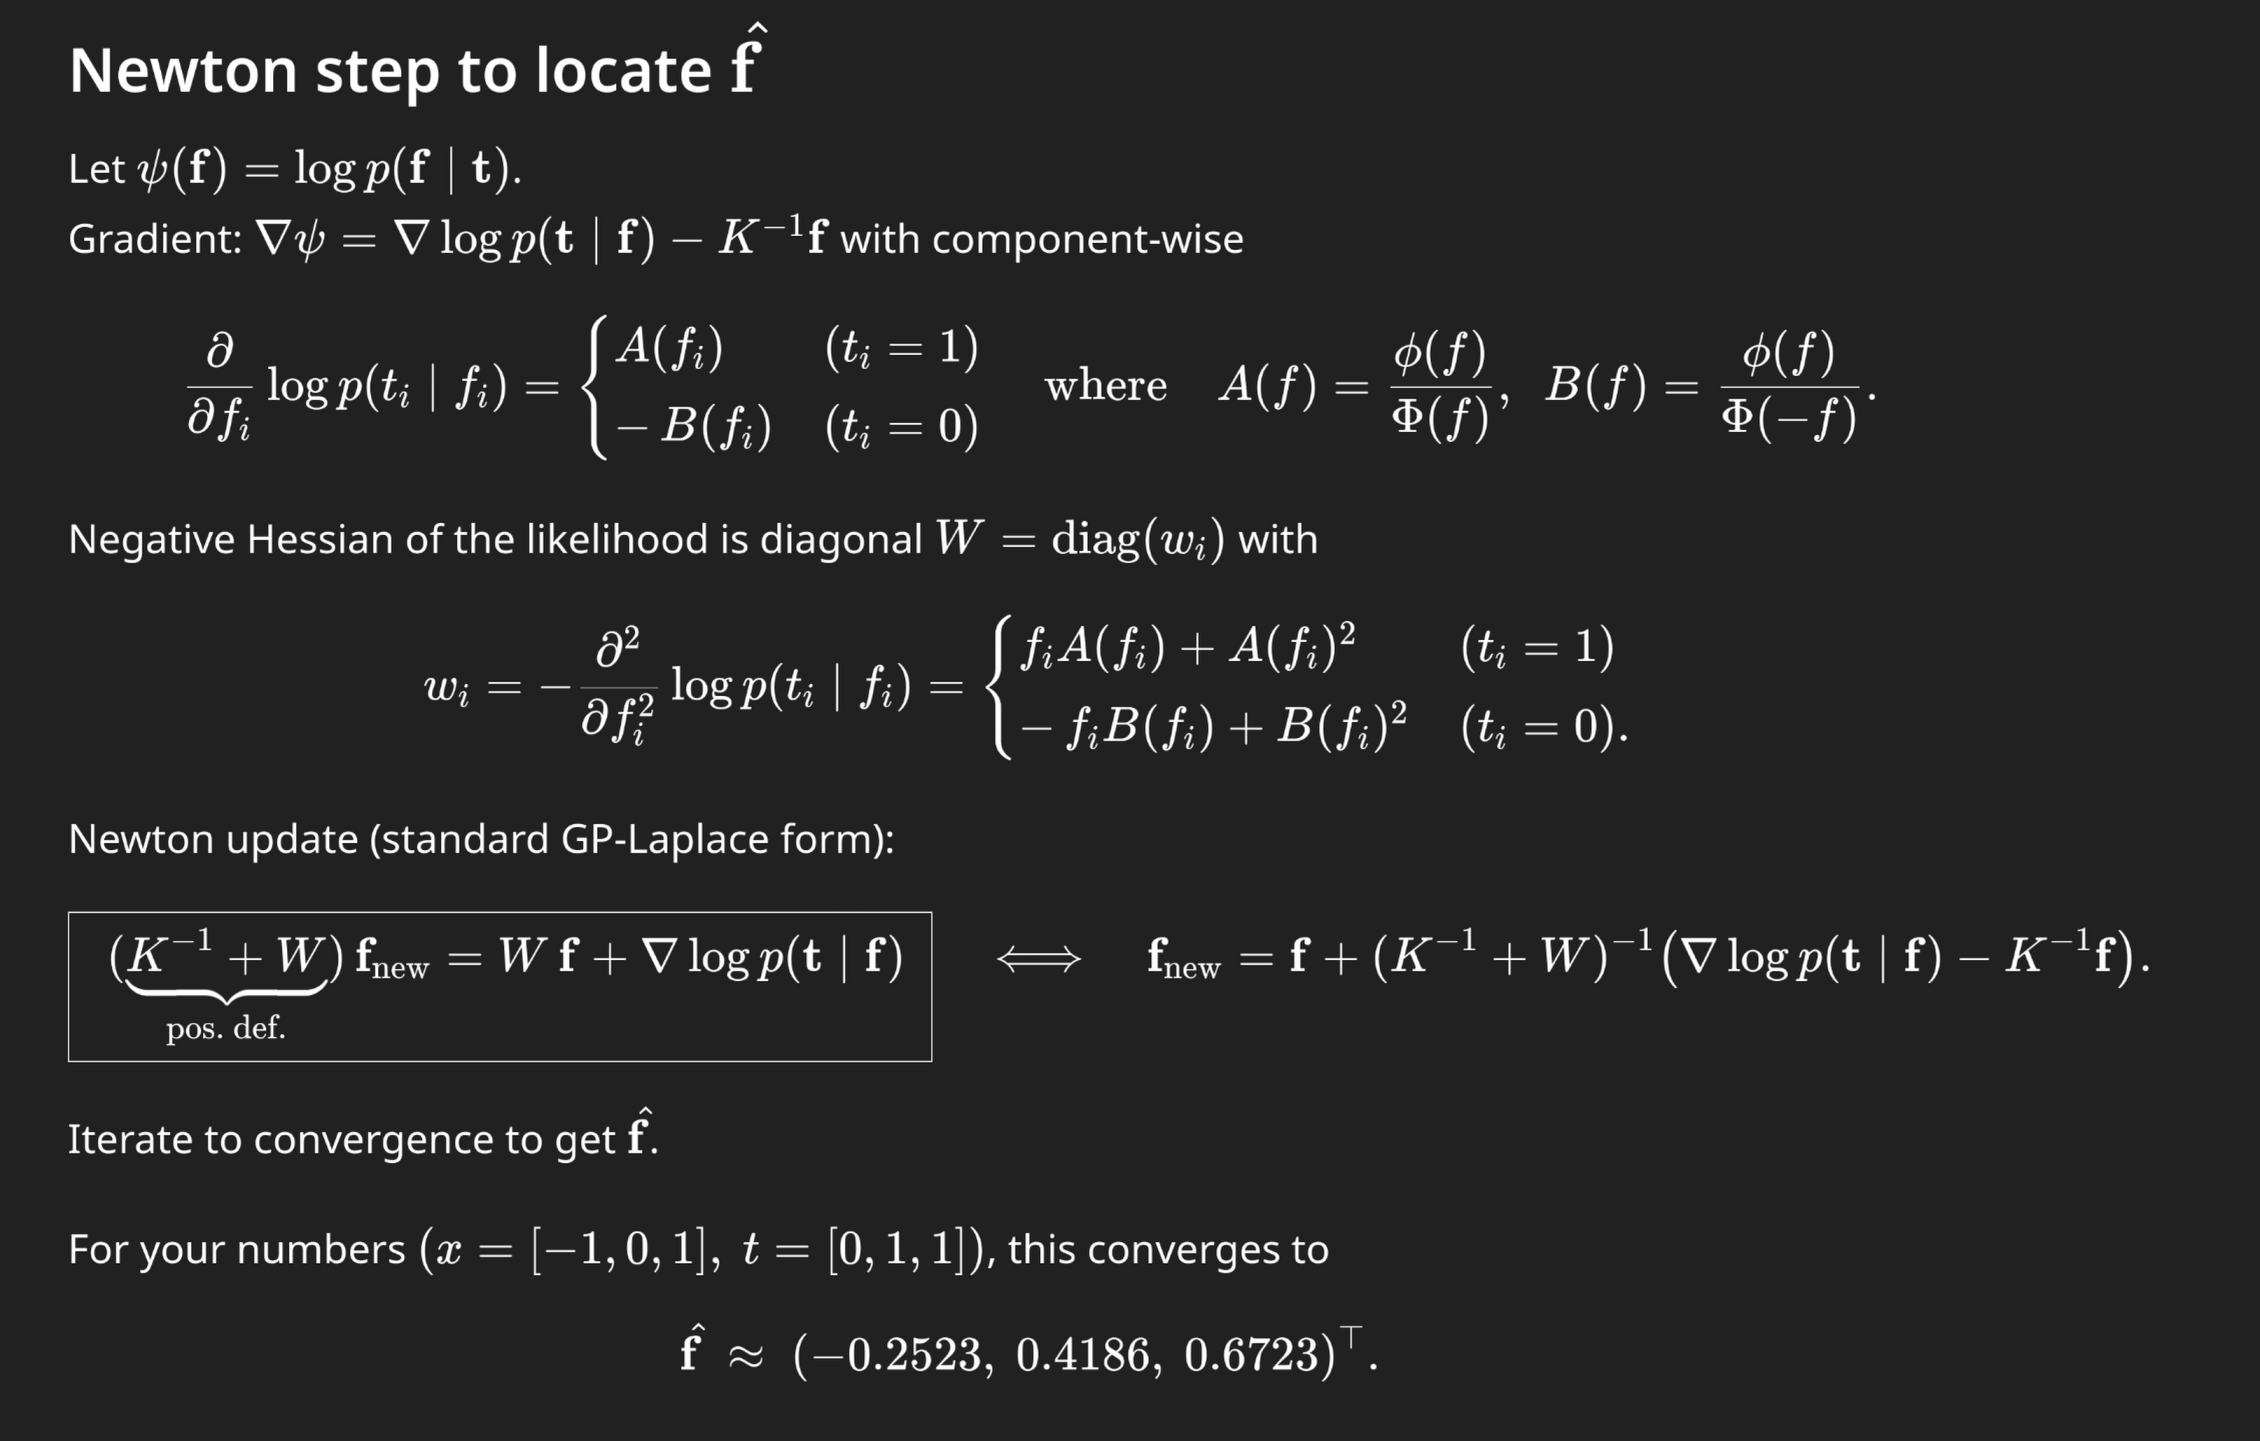
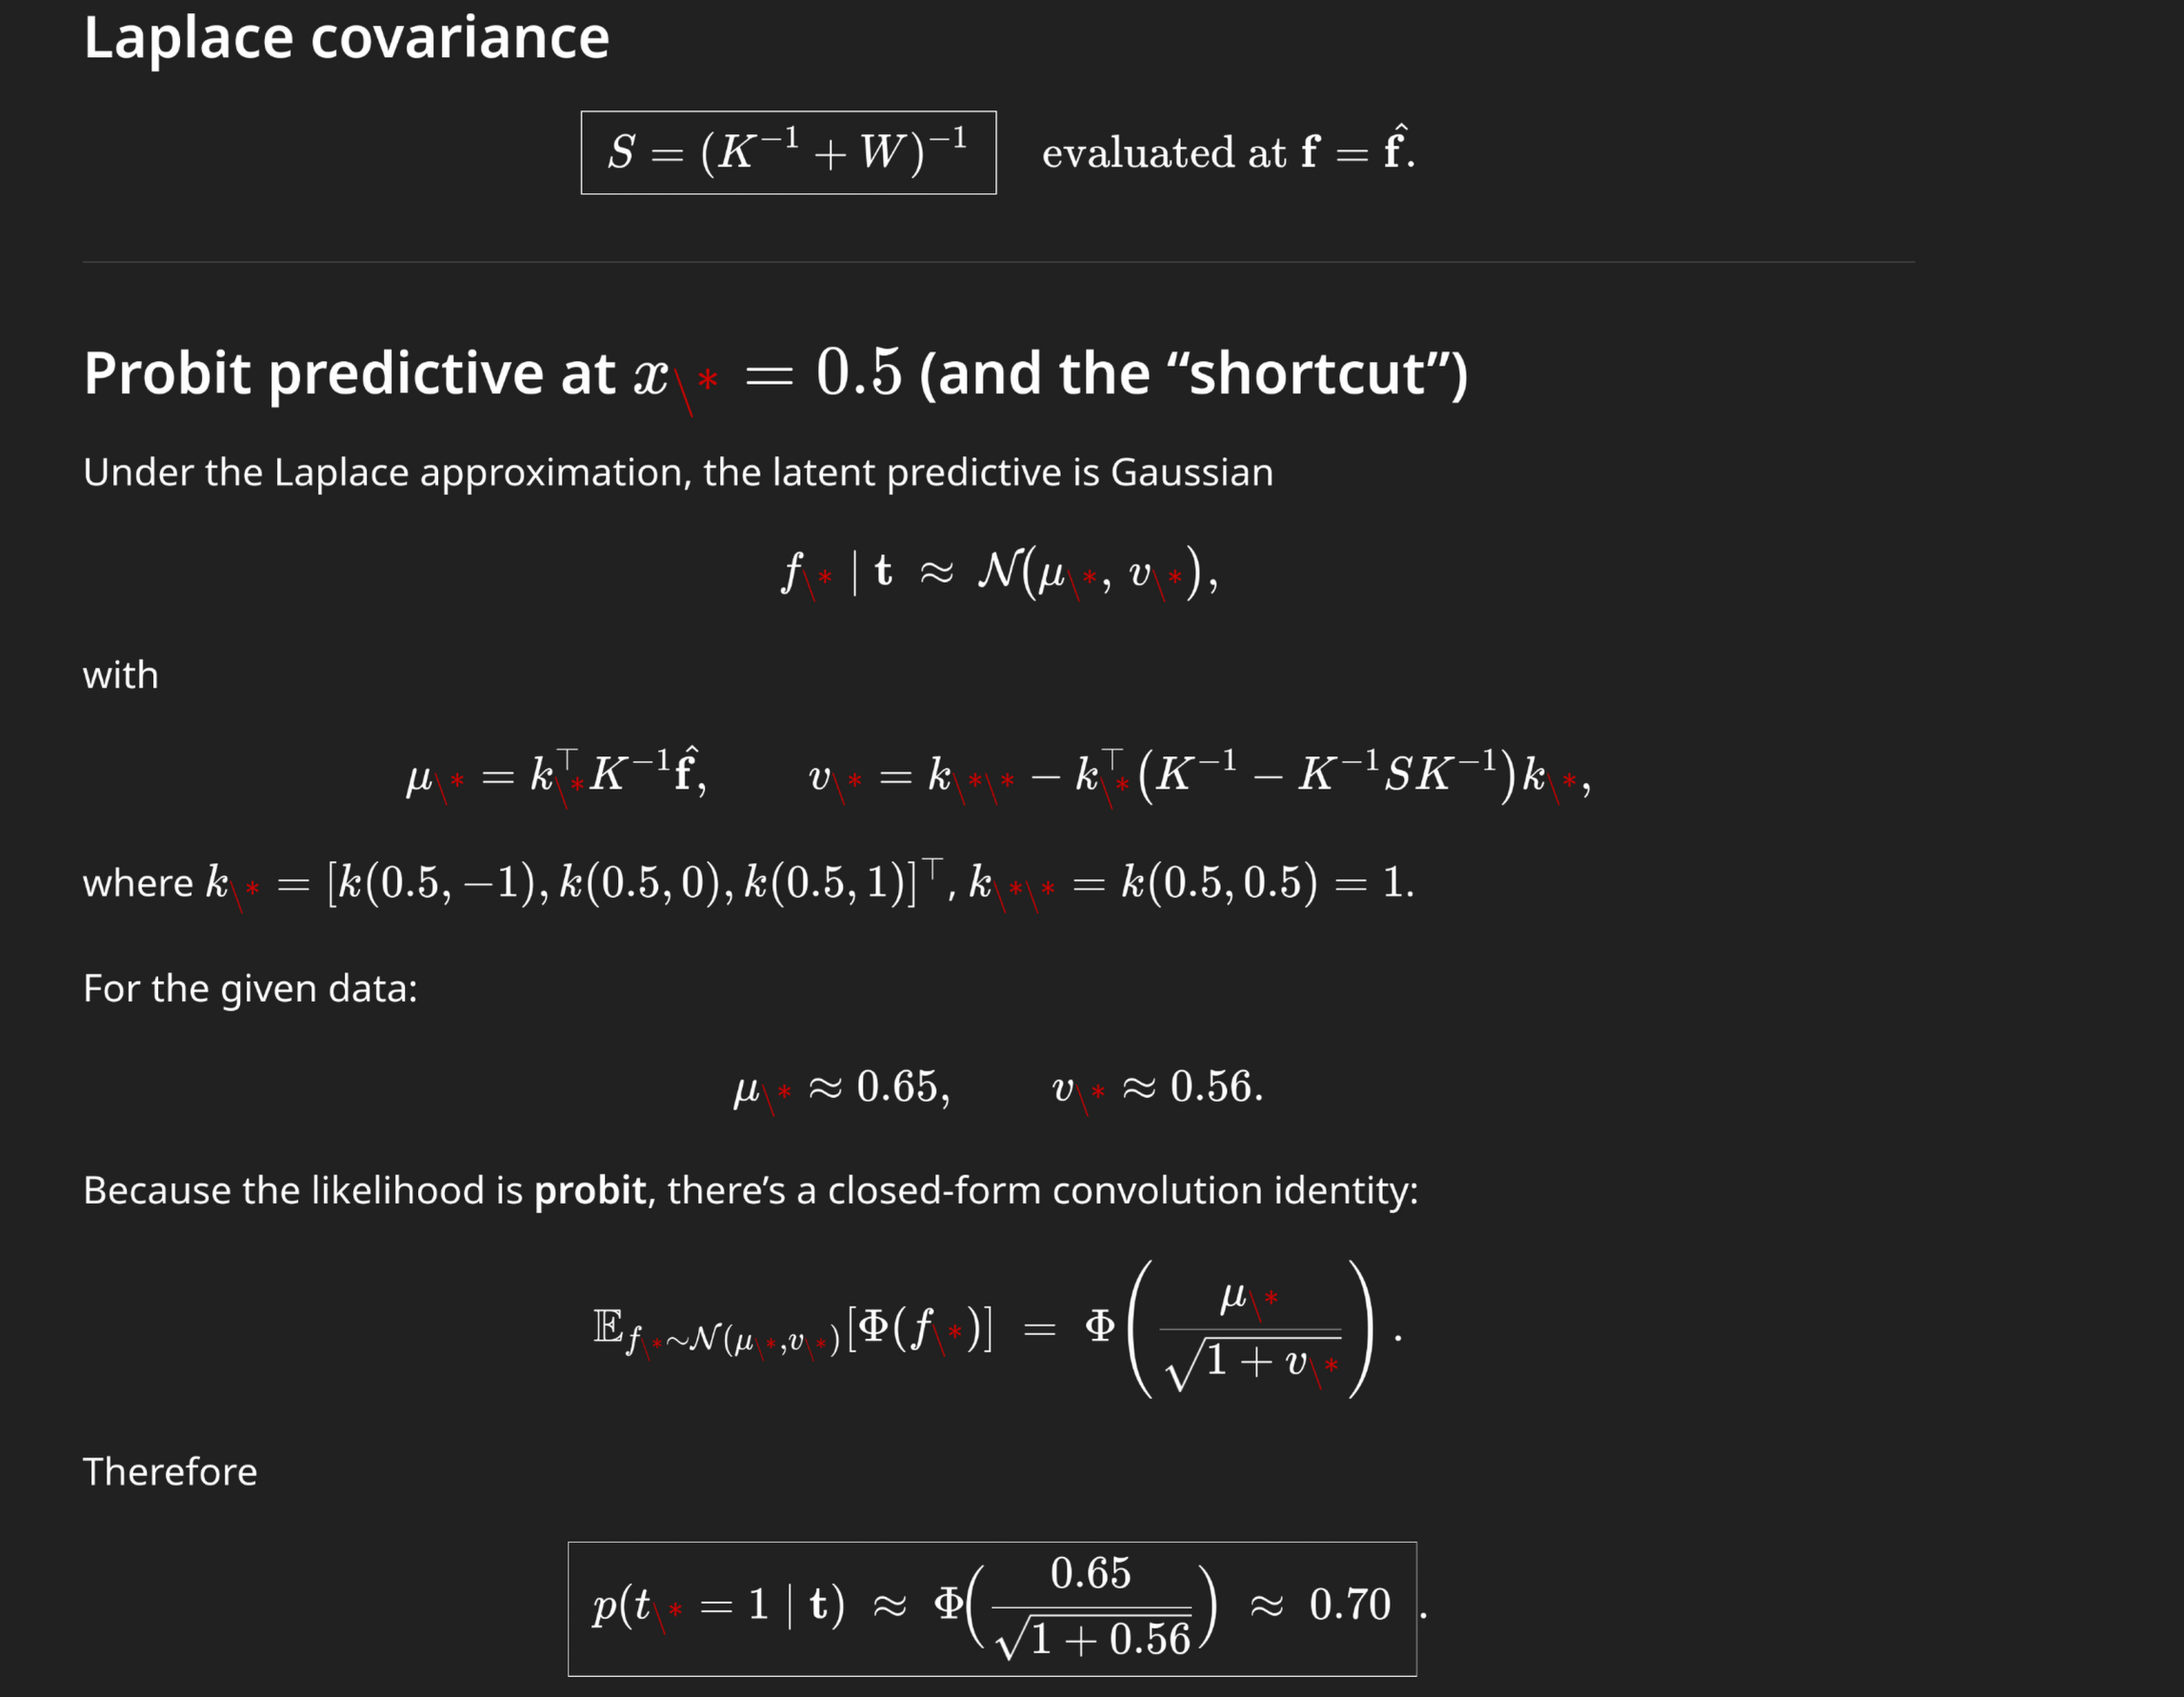

Part 1 — Bayesian linear regression with mixed basis

We observe 
$$
y_n = f(x_n) + \varepsilon_n, \quad \varepsilon_n \sim \mathcal{N}(0, \sigma^2)
$$
and
$$
f(x) = w_0 + w_1 x + w_2 x^2 + w_3 \sin(0.5x) 
= w^\top \phi(x), 
\quad \phi(x) = [1, \, x, \, x^2, \, \sin(0.5x)]^\top.
$$

Data ($N = 6$):
$$
x = [-2.2, \, -0.7, \, 0.0, \, 1.3, \, 2.4, \, 3.0]
$$
$$
y = [-0.9, \, -0.1, \, 0.2, \, 1.5, \, 2.6, \, 2.7]
$$

Priors
$$
w_j \stackrel{\text{iid}}{\sim} \mathcal{N}(0, \alpha^{-1}), \quad \alpha = 1.
$$
Noise: $\sigma = 0.30$ (fixed).  
Let $\Phi \in \mathbb{R}^{N \times 4}$ be the design matrix.

---

Q1.1 (Easy)
Write the analytical likelihood $p(y \mid w, \Phi, \sigma^2)$ and the marginal likelihood $p(y \mid \alpha, \sigma)$ in closed form.

Hint: Linear–Gaussian identities. Your expressions should make the roles of $\Phi$, $\alpha$, and $\sigma$ explicit.  
(Study: Lecture 4 ``Bayesian linear regression: key equations'' \& ``Marginal likelihood'').

---

Q1.2 (Medium)
Compute the MLE $\hat{w}_{\mathrm{ML}}$. Report the fitted mean 
$$
\hat{f}(x) = \hat{w}_{\mathrm{ML}}^\top \phi(x)
$$
at $x = 1.0$.

Hint: Solve $(\Phi^\top \Phi) \hat{w} = \Phi^\top y$.  
(Study: derivation vs. plug-in predictive on slides 5–6).

---

Q1.3 (Medium)
Derive the posterior $p(w \mid y)$ and report the \textbf{posterior mean} $m$ and the \textbf{marginal posterior standard deviations} for each $w_j$.

Hint:
$$
S = (\alpha I + \beta \Phi^\top \Phi)^{-1}, 
\quad m = \beta S \Phi^\top y, 
\quad \beta = \sigma^{-2}.
$$
(Study: slide 4).

---

Q1.4 (Medium)
Compute the posterior predictive $p(y_* \mid y, x_*)$ at $x_* = 2.0$.  
Report the \textbf{mean}, \textbf{SD}, and a \textbf{95\% credibility interval}.

Hint:
$$
\mathrm{Var}(y_* \mid y) = \phi_*^\top S \phi_* + \sigma^2.
$$
(Study: slides 5–6).

---

Q1.5 (Hard, reformulated)
Suppose a colleague insists on using the \textit{plug-in MAP} instead of the full posterior predictive.
Give conditions under which the two predictive means and variances will be close, and justify using equations.

Hint: Consider the size of $S$ and effective data size/conditioning of $\Phi^\top \Phi$.
(Study: ``Poor man’s Bayes / MAP'' on slide 6).
